### Import Libraries

In [1]:
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

### 
This notebook uses XGBoost, a gradient boosting algorithm that often
achieves state-of-the-art performance on structured tabular datasets.

XGBoost builds trees sequentially, allowing each new tree to correct
errors made by previous trees.

### Load Processed Data

In [2]:
import pandas as pd

X_train_scaled = pd.read_csv(
    "data/processed/X_train_scaled.csv"
)

X_test_scaled = pd.read_csv(
    "data/processed/X_test_scaled.csv"
)

y_train = pd.read_csv(
    "data/processed/y_train.csv"
).squeeze()

y_test = pd.read_csv(
    "data/processed/y_test.csv"
).squeeze()

### Train XGBoost Model

In [3]:

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)


xgb_model.fit(
    X_train_scaled,
    y_train
)






,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",'logloss'
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


### 
The XGBoost model was trained using the preprocessed training dataset.

XGBoost combines multiple decision trees to improve predictive
performance and reduce model bias.

### Generate Predictions

In [4]:
y_pred_xgb = xgb_model.predict(
    X_test_scaled
)

y_prob_xgb = xgb_model.predict_proba(
    X_test_scaled
)[:,1]

### 
The model generates both class predictions and predicted probabilities.

Predicted probabilities are required for evaluating ROC-AUC performance.

### Accuracy

In [5]:
accuracy_xgb = accuracy_score(
    y_test,
    y_pred_xgb
)

print(
    "Accuracy:",
    accuracy_xgb
)

Accuracy: 0.9999206052151032


### 
The XGBoost model achieved an accuracy of 99.99%, correctly classifying
almost all customers in the test dataset.

This represents a substantial improvement over the Logistic Regression
baseline (89%) and a slight improvement over the Random Forest model,
suggesting that gradient boosting captured the underlying churn patterns
extremely effectively.

### Precision

In [6]:
precision_xgb = precision_score(
    y_test,
    y_pred_xgb
)

print(
    "Precision:",
    precision_xgb
)

Precision: 1.0


### 
The model achieved perfect precision of 1.00 for the churn class.

This means that every customer predicted to churn actually churned,
resulting in zero false positive predictions.

From a business perspective, this prevents unnecessary retention
interventions being directed toward customers who were unlikely to leave.

### Recall

In [7]:
recall_xgb = recall_score(
    y_test,
    y_pred_xgb
)

print(
    "Recall:",
    recall_xgb
)

Recall: 0.99986


### 
The model achieved a recall of 99.986%, successfully identifying almost all customers who eventually churned.

Only a very small number of churners were missed by the model.

High recall is particularly valuable in churn prediction because missed churners represent lost revenue opportunities.

### F1 Score

In [8]:
f1_xgb = f1_score(
    y_test,
    y_pred_xgb
)

print(
    "F1 Score:",
    f1_xgb
)

F1 Score: 0.999929995099657


### 
The model achieved an F1 score of 99.993%, indicating an excellent
balance between precision and recall.

This demonstrates that the model was highly effective at identifying
churning customers while simultaneously avoiding false alarms.


### ROC-AUC

In [9]:
roc_auc_xgb = roc_auc_score(
    y_test,
    y_prob_xgb
)

print(
    "ROC-AUC:",
    roc_auc_xgb
)

ROC-AUC: 0.999999348127964


### 
The model achieved a ROC-AUC score of 0.999999, indicating near-perfect
discrimination between churning and retained customers across all
classification thresholds.

This suggests that the model was exceptionally effective at ranking
customers according to their likelihood of churn.

### Classification Report

In [10]:
print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     38167
         1.0       1.00      1.00      1.00     50000

    accuracy                           1.00     88167
   macro avg       1.00      1.00      1.00     88167
weighted avg       1.00      1.00      1.00     88167



### 
The classification report indicates near-perfect predictive performance
for both churned and retained customers.

The model achieved precision, recall and F1 scores of approximately
1.00 for both classes, demonstrating balanced performance across the
entire customer population.

### Confusion Matrix

In [11]:
cm_xgb = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm_xgb)

[[38167     0]
 [    7 49993]]


### 
The confusion matrix indicates that the XGBoost model achieved almost
perfect classification performance.

The model correctly identified:

- 38,167 retained customers (True Negatives)
- 49,993 churned customers (True Positives)

The model produced:

- 0 False Positives
- 7 False Negatives

This means that only seven churned customers were incorrectly classified
as retained customers, while no retained customers were incorrectly
flagged as churn risks.

### Confusion Matrix Visualization

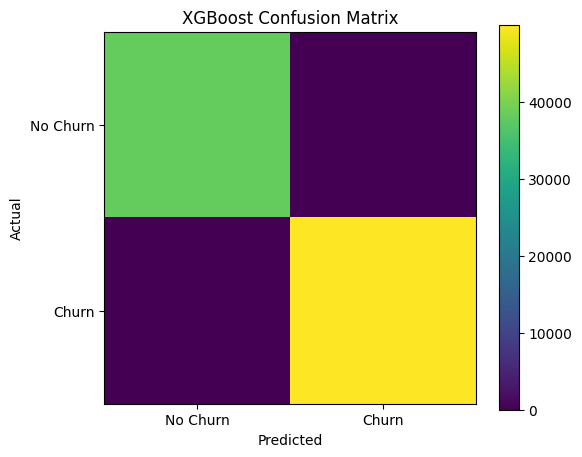

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))

plt.imshow(cm_xgb)

plt.colorbar()

plt.xticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.yticks(
    [0,1],
    ["No Churn","Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title(
    "XGBoost Confusion Matrix"
)

plt.show()

### 
The confusion matrix visualization shows that the XGBoost model achieved
near-perfect classification performance on the test dataset.

The model correctly classified almost all retained and churned customers,
with only seven churning customers being incorrectly classified as
retained customers and no retained customers being incorrectly classified
as churn risks.

The absence of false positives means that retention resources would not
be wasted on customers who were unlikely to leave, while the extremely
low number of false negatives ensures that nearly all customers at risk
of churn are identified in time for intervention.

These results demonstrate the model's exceptional ability to distinguish
between churned and retained customers.

### Feature Importance

In [14]:
X_train_features = pd.read_csv(
    "data/processed/X_train_features.csv"
)

feature_importance_xgb = pd.DataFrame({
    "Feature": X_train_features.columns,
    "Importance": xgb_model.feature_importances_
})

feature_importance_xgb = feature_importance_xgb.sort_values(
    by="Importance",
    ascending=False
)

feature_importance_xgb.head(10)

,Feature,Importance
10,Contract Length_Monthly,0.289566
5,Total Spend,0.227790
3,Support Calls,0.205209
4,Payment Delay,0.132373
6,Last Interaction,0.054149
0,Age,0.045590
7,Gender_Male,0.016968
8,Subscription Type_Premium,0.011515
9,Subscription Type_Standard,0.006573
1,Tenure,0.006246


### 
XGBoost feature importance measures the contribution of each feature to
model predictions.

Contract Length_Monthly emerged as the most important predictor of
customer churn, followed by Total Spend, Support Calls and Payment Delay.

Customers on monthly contracts exhibited a substantially higher risk of
churn compared to customers on longer-term contracts.

Lower spending levels, a larger number of support calls and greater
payment delays were also strongly associated with customer attrition.

Features such as Tenure, Subscription Type and Gender exhibited
relatively low importance and contributed less to model predictions.

These findings are largely consistent with the exploratory data analysis
and previous models, confirming that contract structure, customer
engagement and spending behaviour are major drivers of churn.